<a href="https://colab.research.google.com/github/Davron030901/Machine_Learning/blob/main/toshkent_weather_forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌡 Toshkent Ob-havo Harorat Bashorati
## Ertangi kunlik maksimal haroratni Machine Learning bilan bashorat qilish

**Dataset:** 5.5 yillik soatlik ob-havo ma'lumoti (2020-2026)
**Target:** Ertangi kunning maksimal harorati (°C)
**Muallif:** Davron

### Modellar:
1. Linear Regression (baseline)
2. Ridge Regression
3. Random Forest
4. Gradient Boosting
5. XGBoost
6. LightGBM


## 1. 📦 Kerakli kutubxonalarni o'rnatish

In [ ]:
!pip install xgboost lightgbm scikit-learn pandas numpy matplotlib seaborn joblib -q
print("✅ Barcha kutubxonalar o'rnatildi")


✅ Barcha kutubxonalar o'rnatildi


## 2. 📚 Import va sozlamalar

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import joblib
import os
from datetime import datetime, timedelta
from collections import defaultdict

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
plt.style.use('seaborn-v0_8-whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Importlar tayyor")
print(f"   XGBoost: {xgb.__version__}")
print(f"   LightGBM: {lgb.__version__}")


✅ Importlar tayyor
   XGBoost: 3.2.0
   LightGBM: 4.6.0


## 3. 📂 Ma'lumotni yuklash

In [ ]:
# Datasetni GitHub'dan yuklab olish
import urllib.request

url = "https://raw.githubusercontent.com/Davron030901/Machine_Learning/main/data/toshkent_dataset_5_5yil.csv"
filename = "toshkent_dataset_5_5yil.csv"

urllib.request.urlretrieve(url, filename)
print(f"✅ Fayl yuklab olindi: {filename}")


✅ Fayl yuklab olindi: toshkent_dataset_5_5yil.csv


In [ ]:
# CSV ni o'qish
df_raw = pd.read_csv(filename, encoding='utf-8-sig')
df_raw['datetime'] = pd.to_datetime(df_raw['datetime'])
df_raw = df_raw.sort_values('datetime').reset_index(drop=True)

print(f"📊 Dataset hajmi: {df_raw.shape[0]:,} qator × {df_raw.shape[1]} ustun")
print(f"📅 Davr: {df_raw['datetime'].min().date()} → {df_raw['datetime'].max().date()}")
print(f"\n🌡 Harorat: min={df_raw['temperature_2m'].min():.1f}°C, "
      f"max={df_raw['temperature_2m'].max():.1f}°C, "
      f"mean={df_raw['temperature_2m'].mean():.1f}°C")
df_raw.head(3)


📊 Dataset hajmi: 48,768 qator × 17 ustun
📅 Davr: 2020-11-27 → 2026-06-20

🌡 Harorat: min=-27.4°C, max=44.7°C, mean=15.4°C


,datetime,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation,cloud_cover,co,no,no2,o3,so2,pm2_5,pm10,nh3,aqi
0,2020-11-27 00:00:00,-0.300,72,4.000,63,968.000,0.000,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-11-27 01:00:00,-0.700,74,2.900,90,967.500,0.000,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-11-27 02:00:00,-1.100,72,2.900,90,967.300,0.000,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. 🔍 EDA — Ma'lumotni tushunish

In [ ]:
nulls = df_raw.isnull().sum()
null_pct = (nulls / len(df_raw) * 100).round(1)
null_df = pd.DataFrame({'Null soni': nulls, 'Foiz (%)': null_pct})
null_df = null_df[null_df['Null soni'] > 0]
print("⚠️ Bo'sh qiymatlar:")
print(null_df.to_string())


⚠️ Bo'sh qiymatlar:
       Null soni  Foiz (%)
co           904     1.900
no           904     1.900
no2          904     1.900
o3           904     1.900
so2          904     1.900
pm2_5        904     1.900
pm10         904     1.900
nh3          904     1.900
aqi          904     1.900


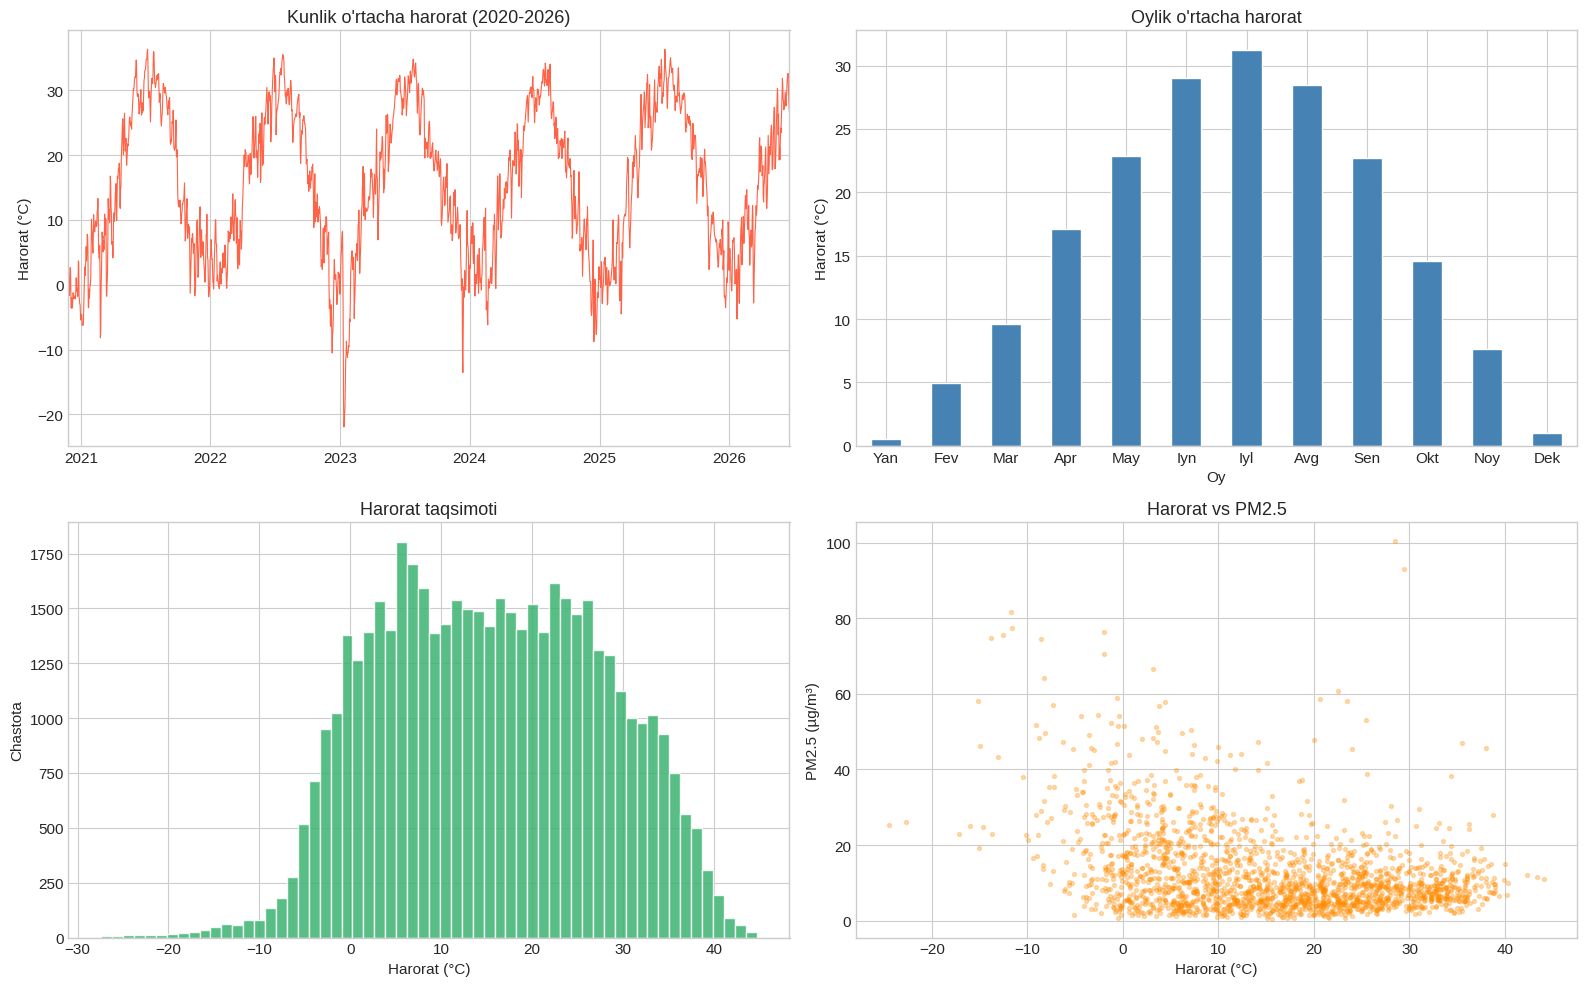

✅ EDA grafigi saqlandi: eda_overview.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
df_raw.set_index('datetime')['temperature_2m'].resample('D').mean().plot(ax=ax, lw=0.8, color='tomato')
ax.set_title("Kunlik o'rtacha harorat (2020-2026)", fontsize=13)
ax.set_ylabel('Harorat (°C)')
ax.set_xlabel('')

ax = axes[0, 1]
monthly = df_raw.groupby(df_raw['datetime'].dt.month)['temperature_2m'].mean()
monthly.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title("Oylik o'rtacha harorat", fontsize=13)
ax.set_xlabel('Oy')
ax.set_ylabel('Harorat (°C)')
ax.set_xticklabels(['Yan','Fev','Mar','Apr','May','Iyn','Iyl','Avg','Sen','Okt','Noy','Dek'], rotation=0)

ax = axes[1, 0]
ax.hist(df_raw['temperature_2m'].dropna(), bins=60, color='mediumseagreen', edgecolor='white', alpha=0.85)
ax.set_title('Harorat taqsimoti', fontsize=13)
ax.set_xlabel('Harorat (°C)')
ax.set_ylabel('Chastota')

ax = axes[1, 1]
sample_n = min(2000, df_raw[['temperature_2m','pm2_5']].dropna().shape[0])
sample = df_raw[['temperature_2m','pm2_5']].dropna().sample(sample_n, random_state=42)
ax.scatter(sample['temperature_2m'], sample['pm2_5'], alpha=0.3, s=8, color='darkorange')
ax.set_title('Harorat vs PM2.5', fontsize=13)
ax.set_xlabel('Harorat (°C)')
ax.set_ylabel('PM2.5 (µg/m³)')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ EDA grafigi saqlandi: eda_overview.png")


## 5. ⚙️ Preprocessing — Ma'lumotni tayyorlash

In [ ]:
df_raw['date'] = df_raw['datetime'].dt.date

daily = df_raw.groupby('date').agg(
    temp_max   = ('temperature_2m', 'max'),
    temp_min   = ('temperature_2m', 'min'),
    temp_mean  = ('temperature_2m', 'mean'),
    temp_std   = ('temperature_2m', 'std'),
    humidity   = ('relative_humidity_2m', 'mean'),
    wind_speed = ('wind_speed_10m', 'mean'),
    pressure   = ('surface_pressure', 'mean'),
    precip     = ('precipitation', 'sum'),
    cloud      = ('cloud_cover', 'mean'),
    pm2_5      = ('pm2_5', 'mean'),
    pm10       = ('pm10', 'mean'),
    aqi        = ('aqi', 'mean'),
).reset_index()

daily['date'] = pd.to_datetime(daily['date'])
daily = daily.sort_values('date').reset_index(drop=True)

print(f"📅 Kunlik dataset: {len(daily)} kun")
print(f"   {daily['date'].min().date()} → {daily['date'].max().date()}")
daily.head(3)


📅 Kunlik dataset: 2032 kun
   2020-11-27 → 2026-06-20


,date,temp_max,temp_min,temp_mean,temp_std,humidity,wind_speed,pressure,precip,cloud,pm2_5,pm10,aqi
0,2020-11-27,10.900,-1.100,3.962,3.851,62.250,6.558,966.508,0.000,96.750,13.915,15.582,2.250
1,2020-11-28,4.600,-2.800,0.754,2.082,82.667,9.771,983.788,7.600,65.375,9.533,11.006,1.667
2,2020-11-29,4.400,-5.200,-1.658,3.192,68.625,8.629,983.887,0.000,1.792,11.720,14.016,2.167


In [ ]:
df = daily.copy()

df['month']      = df['date'].dt.month
df['day_of_year']= df['date'].dt.dayofyear
df['week']       = df['date'].dt.isocalendar().week.astype(int)
df['season']     = df['month'].map({
    12:0,1:0,2:0,
    3:1,4:1,5:1,
    6:2,7:2,8:2,
    9:3,10:3,11:3
})

df['month_sin']  = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']  = np.cos(2 * np.pi * df['month'] / 12)
df['doy_sin']    = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['doy_cos']    = np.cos(2 * np.pi * df['day_of_year'] / 365)

for lag in [1, 2, 3, 7, 14]:
    df[f'temp_max_lag{lag}']  = df['temp_max'].shift(lag)
    df[f'temp_mean_lag{lag}'] = df['temp_mean'].shift(lag)

for window in [3, 7, 14, 30]:
    df[f'temp_max_roll{window}']  = df['temp_max'].shift(1).rolling(window).mean()
    df[f'temp_max_std{window}']   = df['temp_max'].shift(1).rolling(window).std()
    df[f'temp_mean_roll{window}'] = df['temp_mean'].shift(1).rolling(window).mean()

df['temp_max_diff1']  = df['temp_max'].shift(1).diff(1)
df['temp_max_diff7']  = df['temp_max'].shift(1).diff(7)
df['temp_range']      = df['temp_max'].shift(1) - df['temp_min'].shift(1)

df['pm2_5_lag1']  = df['pm2_5'].shift(1)
df['aqi_lag1']    = df['aqi'].shift(1)
df['precip_lag1'] = df['precip'].shift(1)
df['cloud_lag1']  = df['cloud'].shift(1)

print(f"✅ Feature engineering: {df.shape[1]} ustun")

df['target'] = df['temp_max'].shift(-1)

df_clean = df.dropna().reset_index(drop=True)
print(f"✅ Tozalangan dataset: {len(df_clean)} kun")
df_clean.head(3)


✅ Feature engineering: 50 ustun
✅ Tozalangan dataset: 1984 kun


,date,temp_max,temp_min,temp_mean,temp_std,humidity,wind_speed,pressure,precip,cloud,...,temp_max_std30,temp_mean_roll30,temp_max_diff1,temp_max_diff7,temp_range,pm2_5_lag1,aqi_lag1,precip_lag1,cloud_lag1,target
0,2020-12-27,1.800,-3.000,-1.838,1.310,87.833,6.550,979.658,4.400,98.583,...,2.688,-0.714,-3.700,-0.900,2.900,11.192,1.542,1.800,99.375,-0.200
1,2020-12-28,-0.200,-4.800,-2.367,1.204,83.292,2.404,980.288,0.000,87.500,...,2.426,-0.908,-3.400,1.200,4.800,6.903,1.167,4.400,98.583,2.500
2,2020-12-29,2.500,-6.100,-2.938,3.071,82.750,6.333,978.171,0.000,32.458,...,2.544,-1.012,-2.000,-3.700,4.600,9.509,1.958,0.000,87.500,3.200


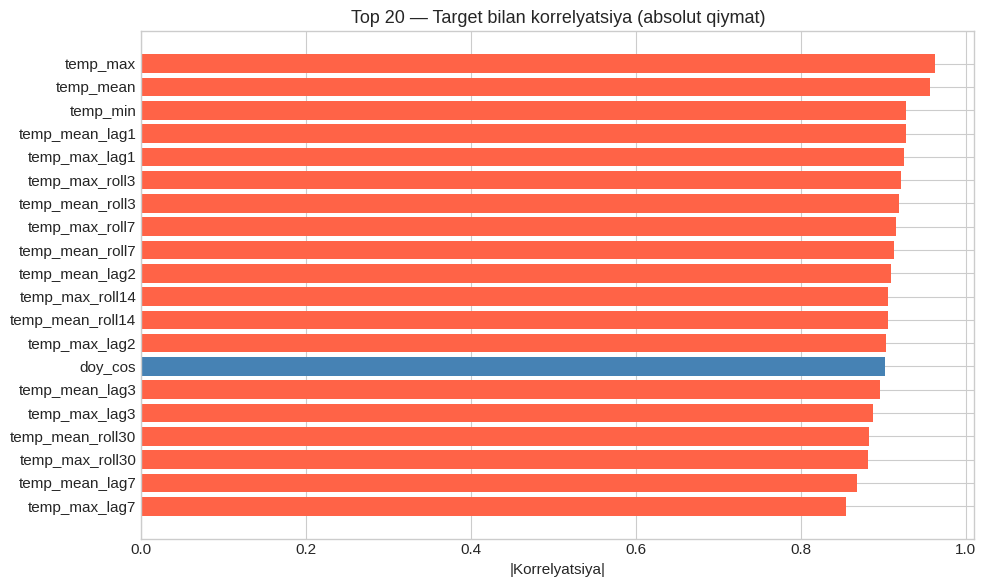

✅ Korrelyatsiya grafigi saqlandi


In [ ]:
feature_cols = [c for c in df_clean.columns if c not in ['date', 'target']]
corr_with_target = df_clean[feature_cols + ['target']].corr()['target'].drop('target')
top_corr = corr_with_target.abs().sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
colors = ['tomato' if corr_with_target[i] >= 0 else 'steelblue' for i in top_corr.index]
plt.barh(top_corr.index[::-1], top_corr.values[::-1], color=colors[::-1])
plt.title('Top 20 — Target bilan korrelyatsiya (absolut qiymat)', fontsize=13)
plt.xlabel('|Korrelyatsiya|')
plt.tight_layout()
plt.savefig('correlation.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Korrelyatsiya grafigi saqlandi")


## 6. ✂️ Train / Test Split (vaqt bo'yicha)

In [ ]:
FEATURE_COLS = [c for c in df_clean.columns if c not in ['date', 'target',
    'temp_max', 'temp_min', 'temp_mean', 'temp_std']]

X = df_clean[FEATURE_COLS]
y = df_clean['target']
dates = df_clean['date']

split_idx = int(len(df_clean) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_test = dates.iloc[split_idx:]

print(f"📊 Train: {len(X_train)} kun ({dates.iloc[0].date()} → {dates.iloc[split_idx-1].date()})")
print(f"📊 Test:  {len(X_test)} kun ({dates.iloc[split_idx].date()} → {dates.iloc[-1].date()})")
print(f"📊 Features: {len(FEATURE_COLS)} ta")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("\n✅ Train/Test split tayyor")


📊 Train: 1587 kun (2020-12-27 → 2025-05-18)
📊 Test:  397 kun (2025-05-19 → 2026-06-19)
📊 Features: 45 ta

✅ Train/Test split tayyor


## 7. 🤖 6 ta Model — Train va Evaluate

In [ ]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te, scaled=False):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    mae  = mean_absolute_error(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    r2   = r2_score(y_te, pred)
    mape = np.mean(np.abs((y_te - pred) / (np.abs(y_te) + 1e-8))) * 100
    print(f"  {name:<25} MAE={mae:.2f}°C  RMSE={rmse:.2f}°C  R²={r2:.4f}  MAPE={mape:.2f}%")
    return {'name': name, 'model': model, 'pred': pred, 'mae': mae, 'rmse': rmse, 'r2': r2, 'mape': mape}

results = []
print("=" * 75)
print(f"{'Model':<25} {'MAE':>12} {'RMSE':>12} {'R²':>10} {'MAPE':>10}")
print("=" * 75)


Model                              MAE         RMSE         R²       MAPE


In [ ]:
m1 = LinearRegression()
r = evaluate("1. Linear Regression", m1, X_train_sc, y_train, X_test_sc, y_test, scaled=True)
results.append(r)


  1. Linear Regression      MAE=2.41°C  RMSE=3.23°C  R²=0.9208  MAPE=26.09%


In [ ]:
m2 = Ridge(alpha=1.0, random_state=RANDOM_STATE)
r = evaluate("2. Ridge Regression", m2, X_train_sc, y_train, X_test_sc, y_test, scaled=True)
results.append(r)


  2. Ridge Regression       MAE=2.41°C  RMSE=3.23°C  R²=0.9207  MAPE=26.76%


In [ ]:
m3 = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=RANDOM_STATE
)
r = evaluate("3. Random Forest", m3, X_train, y_train, X_test, y_test)
results.append(r)


  3. Random Forest          MAE=2.68°C  RMSE=3.46°C  R²=0.9089  MAPE=35.68%


In [ ]:
m4 = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=RANDOM_STATE
)
r = evaluate("4. Gradient Boosting", m4, X_train, y_train, X_test, y_test)
results.append(r)


  4. Gradient Boosting      MAE=2.50°C  RMSE=3.31°C  R²=0.9171  MAPE=30.66%


In [ ]:
m5 = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbosity=0,
)
r = evaluate("5. XGBoost", m5, X_train, y_train, X_test, y_test)
results.append(r)


  5. XGBoost                MAE=2.52°C  RMSE=3.35°C  R²=0.9150  MAPE=30.26%


In [ ]:
m6 = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=40,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=10,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=-1,
)
r = evaluate("6. LightGBM", m6, X_train, y_train, X_test, y_test)
results.append(r)

print("=" * 75)
print("✅ Barcha 6 model train va evaluate qilindi!")


  6. LightGBM               MAE=2.56°C  RMSE=3.38°C  R²=0.9132  MAPE=33.05%
✅ Barcha 6 model train va evaluate qilindi!


## 8. 📊 Modellarni Solishtirish

In [ ]:
results_df = pd.DataFrame([{
    'Model': r['name'], 'MAE (°C)': r['mae'],
    'RMSE (°C)': r['rmse'], 'R²': r['r2'], 'MAPE (%)': r['mape']
} for r in results]).sort_values('MAE (°C)')

print("\n📊 Modellar reytingi (MAE bo'yicha):")
print(results_df.to_string(index=False))

best_name = results_df.iloc[0]['Model']
print(f"\n🏆 Eng yaxshi model: {best_name}")
print(f"   MAE  = {results_df.iloc[0]['MAE (°C)']:.2f}°C")
print(f"   RMSE = {results_df.iloc[0]['RMSE (°C)']:.2f}°C")
print(f"   R²   = {results_df.iloc[0]['R²']:.4f}")



📊 Modellar reytingi (MAE bo'yicha):
               Model  MAE (°C)  RMSE (°C)    R²  MAPE (%)
 2. Ridge Regression     2.412      3.232 0.921    26.760
1. Linear Regression     2.413      3.230 0.921    26.094
4. Gradient Boosting     2.495      3.306 0.917    30.664
          5. XGBoost     2.517      3.347 0.915    30.260
         6. LightGBM     2.562      3.382 0.913    33.048
    3. Random Forest     2.677      3.465 0.909    35.677

🏆 Eng yaxshi model: 2. Ridge Regression
   MAE  = 2.41°C
   RMSE = 3.23°C
   R²   = 0.9207


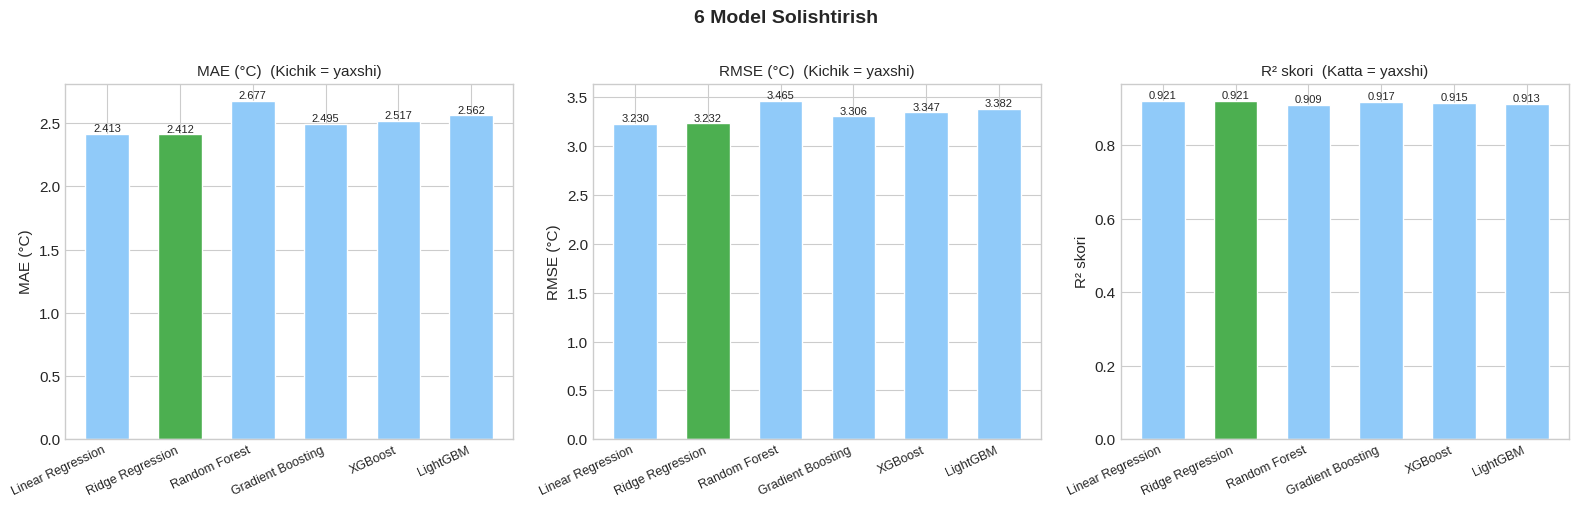

✅ Solishtirish grafigi saqlandi: model_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
names_short = [r['name'].split('. ')[1] for r in results]
palette = ['#4CAF50' if r['name'] == best_name else '#90CAF9' for r in results]

metrics = [
    ([r['mae']  for r in results], 'MAE (°C)',  'Kichik = yaxshi'),
    ([r['rmse'] for r in results], 'RMSE (°C)', 'Kichik = yaxshi'),
    ([r['r2']   for r in results], 'R² skori',  'Katta = yaxshi'),
]
for ax, (vals, ylabel, note) in zip(axes, metrics):
    bars = ax.bar(range(len(names_short)), vals, color=palette, edgecolor='white', width=0.6)
    ax.set_xticks(range(len(names_short)))
    ax.set_xticklabels(names_short, rotation=25, ha='right', fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel}  ({note})', fontsize=11)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('6 Model Solishtirish', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Solishtirish grafigi saqlandi: model_comparison.png")


## 9. 🔬 Eng Yaxshi Model — Chuqur Tahlil

In [ ]:
best_result = min(results, key=lambda x: x['mae'])
best_model  = best_result['model']
best_pred   = best_result['pred']
best_name   = best_result['name']

print(f"🏆 Eng yaxshi model: {best_name}")
print(f"   MAE  = {best_result['mae']:.3f}°C")
print(f"   RMSE = {best_result['rmse']:.3f}°C")
print(f"   R²   = {best_result['r2']:.4f}")
print(f"   MAPE = {best_result['mape']:.2f}%")


🏆 Eng yaxshi model: 2. Ridge Regression
   MAE  = 2.412°C
   RMSE = 3.232°C
   R²   = 0.9207
   MAPE = 26.76%


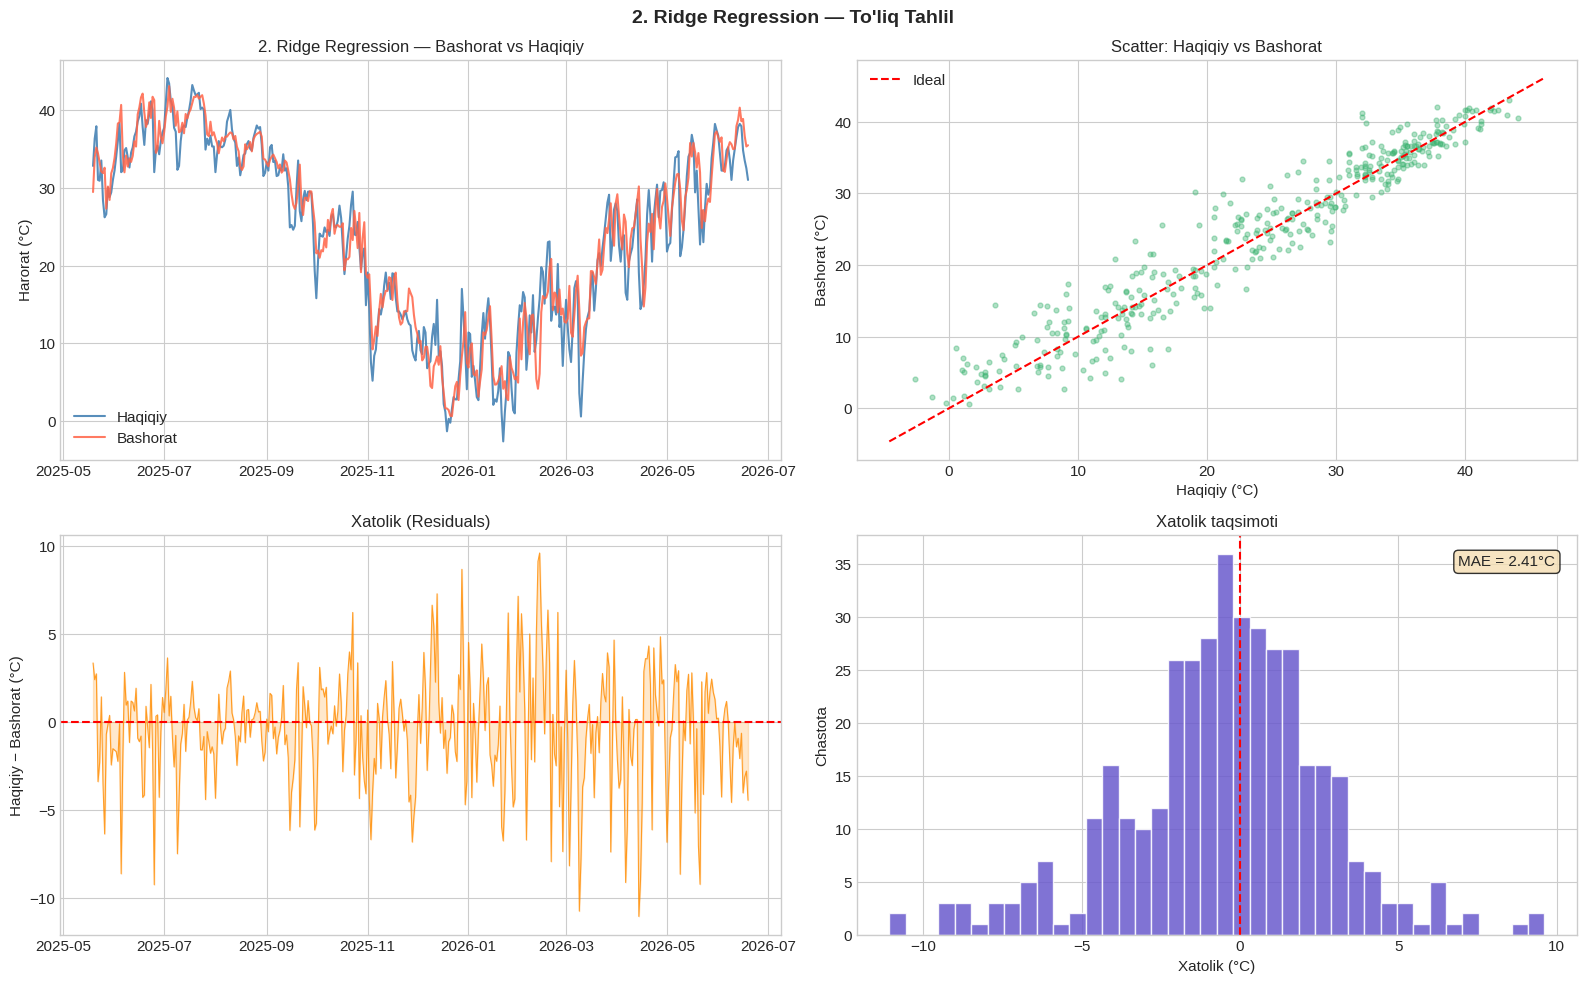

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
ax.plot(dates_test.values, y_test.values, lw=1.5, label='Haqiqiy', color='steelblue', alpha=0.9)
ax.plot(dates_test.values, best_pred,     lw=1.5, label='Bashorat', color='tomato',    alpha=0.85)
ax.set_title(f'{best_name} — Bashorat vs Haqiqiy', fontsize=12)
ax.set_ylabel('Harorat (°C)')
ax.legend()

ax = axes[0, 1]
ax.scatter(y_test, best_pred, alpha=0.4, s=12, color='mediumseagreen')
lims = [min(y_test.min(), best_pred.min()) - 2, max(y_test.max(), best_pred.max()) + 2]
ax.plot(lims, lims, 'r--', lw=1.5, label='Ideal')
ax.set_xlabel('Haqiqiy (°C)')
ax.set_ylabel('Bashorat (°C)')
ax.set_title('Scatter: Haqiqiy vs Bashorat', fontsize=12)
ax.legend()

residuals = y_test.values - best_pred
ax = axes[1, 0]
ax.plot(dates_test.values, residuals, lw=0.8, color='darkorange', alpha=0.8)
ax.axhline(0, color='red', lw=1.5, linestyle='--')
ax.fill_between(dates_test.values, residuals, 0, alpha=0.2, color='darkorange')
ax.set_title('Xatolik (Residuals)', fontsize=12)
ax.set_ylabel('Haqiqiy − Bashorat (°C)')

ax = axes[1, 1]
ax.hist(residuals, bins=40, color='slateblue', edgecolor='white', alpha=0.85)
ax.axvline(0, color='red', lw=1.5, linestyle='--')
ax.set_title('Xatolik taqsimoti', fontsize=12)
ax.set_xlabel('Xatolik (°C)')
ax.set_ylabel('Chastota')
mae_val = np.abs(residuals).mean()
ax.text(0.97, 0.95, f'MAE = {mae_val:.2f}°C', transform=ax.transAxes,
        ha='right', va='top', fontsize=11, bbox=dict(boxstyle='round', fc='wheat', alpha=0.8))

plt.suptitle(f"{best_name} — To'liq Tahlil", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('best_model_analysis.png', dpi=120, bbox_inches='tight')
plt.show()


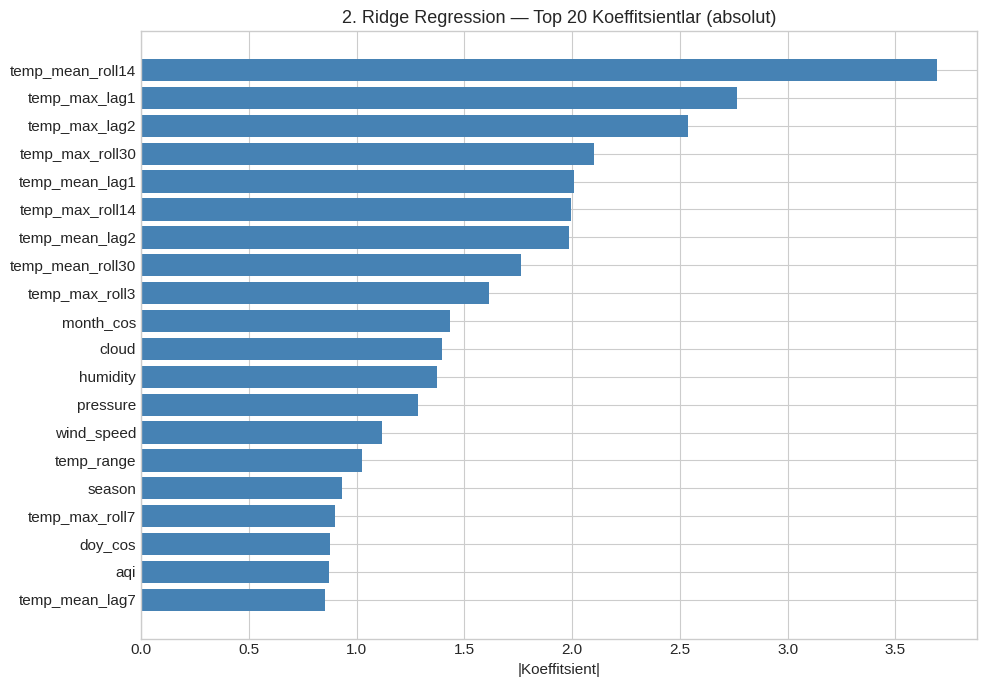

In [ ]:
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=FEATURE_COLS)
    top_fi = fi.sort_values(ascending=False).head(20)

    plt.figure(figsize=(10, 7))
    colors_fi = ['#FF6B6B' if i < 5 else '#4ECDC4' for i in range(len(top_fi))]
    plt.barh(top_fi.index[::-1], top_fi.values[::-1], color=colors_fi[::-1])
    plt.title(f'{best_name} — Top 20 Feature Importance', fontsize=13)
    plt.xlabel('Muhimlik darajasi')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("✅ Feature importance grafigi saqlandi")
else:
    coef = pd.Series(best_model.coef_, index=FEATURE_COLS).abs().sort_values(ascending=False).head(20)
    plt.figure(figsize=(10, 7))
    plt.barh(coef.index[::-1], coef.values[::-1], color='steelblue')
    plt.title(f'{best_name} — Top 20 Koeffitsientlar (absolut)', fontsize=13)
    plt.xlabel('|Koeffitsient|')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
    plt.show()


## 10. 🔄 Cross-Validation (TimeSeriesSplit)

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

print("TimeSeriesSplit (5-fold) Cross-Validation:")
print("-" * 50)

cv_results = {}
for r in results:
    name = r['name']
    model = r['model']
    if 'Linear' in name or 'Ridge' in name:
        X_cv = pd.DataFrame(scaler.fit_transform(X), columns=FEATURE_COLS)
    else:
        X_cv = X

    scores = cross_val_score(model, X_cv, y, cv=tscv,
                              scoring='neg_mean_absolute_error', n_jobs=-1)
    mae_cv = -scores.mean()
    std_cv = scores.std()
    cv_results[name] = {'mean': mae_cv, 'std': std_cv}
    print(f"  {name:<25} CV-MAE = {mae_cv:.3f}°C ± {std_cv:.3f}°C")

print("\n✅ Cross-validation tugadi")


TimeSeriesSplit (5-fold) Cross-Validation:
--------------------------------------------------
  1. Linear Regression      CV-MAE = 2.664°C ± 0.140°C
  2. Ridge Regression       CV-MAE = 2.613°C ± 0.145°C
  3. Random Forest          CV-MAE = 2.979°C ± 0.295°C
  4. Gradient Boosting      CV-MAE = 2.896°C ± 0.360°C
  5. XGBoost                CV-MAE = 2.870°C ± 0.316°C
  6. LightGBM               CV-MAE = 2.942°C ± 0.313°C

✅ Cross-validation tugadi


## 11. 🏆 Yakuniy Natija va Eng Yaxshi Model

In [ ]:
final_df = pd.DataFrame([{
    'Model':      r['name'],
    'Test MAE':   f"{r['mae']:.3f}°C",
    'Test RMSE':  f"{r['rmse']:.3f}°C",
    'Test R²':    f"{r['r2']:.4f}",
    'CV MAE':     f"{cv_results[r['name']]['mean']:.3f}±{cv_results[r['name']]['std']:.3f}°C",
} for r in results])

final_df = final_df.sort_values('Test MAE').reset_index(drop=True)
final_df.index = final_df.index + 1
print("\n" + "="*70)
print("🏆 YAKUNIY NATIJALAR JADVALI")
print("="*70)
print(final_df.to_string())
print("="*70)

winner = min(results, key=lambda x: x['mae'])
print(f"\n✅ TANLANGAN MODEL: {winner['name']}")
print(f"   Test MAE  = {winner['mae']:.3f}°C")
print(f"   Test RMSE = {winner['rmse']:.3f}°C")
print(f"   Test R²   = {winner['r2']:.4f}")
print(f"\n💡 Izoh: MAE={winner['mae']:.1f}°C degani — bashorat o'rtacha ±{winner['mae']:.1f}°C xatoga ega")



🏆 YAKUNIY NATIJALAR JADVALI
                  Model Test MAE Test RMSE Test R²         CV MAE
1   2. Ridge Regression  2.412°C   3.232°C  0.9207  2.613±0.145°C
2  1. Linear Regression  2.413°C   3.230°C  0.9208  2.664±0.140°C
3  4. Gradient Boosting  2.495°C   3.306°C  0.9171  2.896±0.360°C
4            5. XGBoost  2.517°C   3.347°C  0.9150  2.870±0.316°C
5           6. LightGBM  2.562°C   3.382°C  0.9132  2.942±0.313°C
6      3. Random Forest  2.677°C   3.465°C  0.9089  2.979±0.295°C

✅ TANLANGAN MODEL: 2. Ridge Regression
   Test MAE  = 2.412°C
   Test RMSE = 3.232°C
   Test R²   = 0.9207

💡 Izoh: MAE=2.4°C degani — bashorat o'rtacha ±2.4°C xatoga ega


## 12. 💾 Modelni Saqlash

In [ ]:
import json

best_model_final = winner['model']

joblib.dump(best_model_final, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(FEATURE_COLS, 'feature_cols.pkl')

metadata = {
    'model_name':   winner['name'],
    'test_mae':     round(winner['mae'], 4),
    'test_rmse':    round(winner['rmse'], 4),
    'test_r2':      round(winner['r2'], 6),
    'feature_count': len(FEATURE_COLS),
    'feature_cols': FEATURE_COLS,
    'train_size':   len(X_train),
    'test_size':    len(X_test),
    'train_period': f"{dates.iloc[0].date()} — {dates.iloc[split_idx-1].date()}",
    'test_period':  f"{dates.iloc[split_idx].date()} — {dates.iloc[-1].date()}",
    'target':       'ertangi_kun_max_harorat',
    'saved_at':     datetime.now().isoformat(),
}

with open('model_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("✅ Saqlangan fayllar:")
for fname in ['best_model.pkl', 'scaler.pkl', 'feature_cols.pkl', 'model_metadata.json']:
    size = os.path.getsize(fname)
    print(f"   {fname:<30} {size/1024:.1f} KB")

print("\n📦 Keyingi qadam: bu fayllarni AWS S3 ga yuklang")
print("   s3://sizning-bucket/models/best_model.pkl")


✅ Saqlangan fayllar:
   best_model.pkl                 0.9 KB
   scaler.pkl                     2.5 KB
   feature_cols.pkl               0.6 KB
   model_metadata.json            1.2 KB

📦 Keyingi qadam: bu fayllarni AWS S3 ga yuklang
   s3://sizning-bucket/models/best_model.pkl


## 13. 🔮 Bashorat — Misol (Lambda uchun tayyor funksiya)

In [ ]:
def predict_tomorrow_max_temp(recent_daily_df, model, scaler, feature_cols):
    """
    Ertangi kunning maksimal haroratini bashorat qiladi.
    """
    df_tmp = recent_daily_df.copy().sort_values('date').reset_index(drop=True)

    df_tmp['month']       = df_tmp['date'].dt.month
    df_tmp['day_of_year'] = df_tmp['date'].dt.dayofyear
    df_tmp['week']        = df_tmp['date'].dt.isocalendar().week.astype(int)
    df_tmp['season']      = df_tmp['month'].map({12:0,1:0,2:0,3:1,4:1,5:1,6:2,7:2,8:2,9:3,10:3,11:3})
    df_tmp['month_sin']   = np.sin(2 * np.pi * df_tmp['month'] / 12)
    df_tmp['month_cos']   = np.cos(2 * np.pi * df_tmp['month'] / 12)
    df_tmp['doy_sin']     = np.sin(2 * np.pi * df_tmp['day_of_year'] / 365)
    df_tmp['doy_cos']     = np.cos(2 * np.pi * df_tmp['day_of_year'] / 365)

    for lag in [1, 2, 3, 7, 14]:
        df_tmp[f'temp_max_lag{lag}']  = df_tmp['temp_max'].shift(lag)
        df_tmp[f'temp_mean_lag{lag}'] = df_tmp['temp_mean'].shift(lag)

    for window in [3, 7, 14, 30]:
        df_tmp[f'temp_max_roll{window}']  = df_tmp['temp_max'].shift(1).rolling(window).mean()
        df_tmp[f'temp_max_std{window}']   = df_tmp['temp_max'].shift(1).rolling(window).std()
        df_tmp[f'temp_mean_roll{window}'] = df_tmp['temp_mean'].shift(1).rolling(window).mean()

    df_tmp['temp_max_diff1'] = df_tmp['temp_max'].shift(1).diff(1)
    df_tmp['temp_max_diff7'] = df_tmp['temp_max'].shift(1).diff(7)
    df_tmp['temp_range']     = df_tmp['temp_max'].shift(1) - df_tmp['temp_min'].shift(1)
    df_tmp['pm2_5_lag1']     = df_tmp['pm2_5'].shift(1)
    df_tmp['aqi_lag1']       = df_tmp['aqi'].shift(1)
    df_tmp['precip_lag1']    = df_tmp['precip'].shift(1)
    df_tmp['cloud_lag1']     = df_tmp['cloud'].shift(1)

    last_row = df_tmp.iloc[[-1]][feature_cols]

    model_name = type(model).__name__
    if model_name in ('LinearRegression', 'Ridge'):
        last_row_input = scaler.transform(last_row)
    else:
        last_row_input = last_row.values

    pred = model.predict(last_row_input)[0]
    return round(float(pred), 1)


test_window = df_clean.tail(35).copy()
predicted = predict_tomorrow_max_temp(test_window, best_model_final, scaler, FEATURE_COLS)
actual_next = df_clean['target'].iloc[-1]

print(f"🔮 Bashorat (so'nggi kun uchun ertaga): {predicted:.1f}°C")
print(f"✅ Haqiqiy qiymat:                      {actual_next:.1f}°C")
print(f"📏 Xatolik:                             {abs(predicted - actual_next):.1f}°C")


🔮 Bashorat (so'nggi kun uchun ertaga): 34.9°C
✅ Haqiqiy qiymat:                      31.0°C
📏 Xatolik:                             3.9°C


## 14. 📋 Xulosa

### Natijalar
| Qadam | Holat |
|-------|-------|
| Dataset yuklash | ✅ |
| EDA | ✅ |
| Feature Engineering | ✅ |
| Train/Test Split | ✅ |
| 6 model train | ✅ |
| Solishtirish | ✅ |
| Cross-Validation | ✅ |
| Eng yaxshi model saqlash | ✅ |

### Keyingi qadamlar (AWS Deploy)
1. `best_model.pkl`, `scaler.pkl`, `feature_cols.pkl` → **S3 ga yuklash**
2. **Lambda** funksiyasi yozish (S3 dan model yuklash + predict)
3. **EventBridge** har kuni soat 07:00 da chaqirsin
4. **Telegram bot** ga bashorat natijasini yuborsin

### Foydalanilgan texnologiyalar
- `pandas`, `numpy` — ma'lumot qayta ishlash
- `scikit-learn` — Linear/Ridge/RF/GB modellar
- `xgboost` — XGBoost
- `lightgbm` — LightGBM
- `joblib` — model saqlash
